# FLUX Light-Curve example (GRB)

**We provide a python script (get_lctutorial_data.py) that downloads the files and prepares them for analysis. The script creates in the working directory the following files:**
- orientation file (DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori)       
- binned data (tsel_binned_data_local_grbdc3.hdf5, tsel_binned_data_local_galbk.hdf5,tsel_binned_data_galbk_grbdc3.hdf5)
- corresponding yaml file with binning info (bin_grbdc3.yaml, bin_galbk.yaml, bin_galbk_grbdc3.yaml)     
- detector response 
(ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5)     

**The binned data are simulations of GRB 081207680 and Galactic photon background produced for Data Challenge 3. In the data preparation, the background file is cut in time 100s before and after the GRB time window (t_start=1836496300.0, t_stop=1836496388.1, duration=88s) to ensure enough statistics.**

This notebook slices a COSI dataset into time bins, ensuring that a minimum signal-to-noise of 10 is reached in each bin. Perform a fit with 3ML in each of them. It finally examines the time series of flux and fitted spectral parameters. It saves: a txt file of the raw lightcurves (lc.dat); a plot at each iteration of the fit (fit_i.pdf); a txt file (spec_lc.dat) including the mid-point of each time bin with errors, the total counts, the fluxes with asymmetric errors, the fitted parameters with symmetric errors; two plots (raw_flux_counts_lc.pdf, specpars_bk_lc.pdf) of the final time series.

In [4]:
from cosipy import COSILike, BinnedData
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.util import fetch_wasabi_file

from scoords import SpacecraftFrame

from astropy.time import Time, TimeDelta
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import poisson_conf_interval

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from threeML import *
from threeML import Band, PointSource, Model, JointLikelihood, DataList
from cosipy import Band_Eflux
from astromodels import Parameter

from pathlib import Path
from cosipy.pipeline.src.plotting import *

import os
import subprocess
home=os. path. expanduser("~")
home

/opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/io/package_data.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


13:46:56 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=160707;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=244275;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=278609;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=855864;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=287083;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=131288;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=243497;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=207588;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

...

         WARNING   No fermitools installed                                              ]8;id=833379;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=159598;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=178184;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=508228;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=592667;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=928095;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=12362;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=887338;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

'/Users/lauradigesu'

## A function to create time slices with a minimum signal-to-noise.
In this ways the binning in time is coarser in the weak tails of the light-curve and finer around the peak. The function returns the edges of the time slices.

In [15]:
def make_minsn_tslices(yaml_path, hdf5_path, min_sn):
    #   
    data = BinnedData(yaml_path)
    data.load_binned_data_from_hdf5(hdf5_path)
    #
    tstart=np.min(data.binned_data.axes['Time'].edges.value)
    tstop=np.max(data.binned_data.axes['Time'].edges.value)
    max_slices=data.binned_data.axes['Time'].nbins
    step=(tstop-tstart)/max_slices
    tmins = np.array([], dtype=float)
    tmaxs = np.array([], dtype=float)
    #
    tmax=tstart
    for i in range (max_slices):
        #
        tmin=tmax
        tmax_i=tstart+(i+1)*step
        #
        sou_min = np.where(data.binned_data.axes['Time'].edges.value >= tmin)[0][0]
        sou_max = np.where(data.binned_data.axes['Time'].edges.value <= tmax_i)[0][-1]
        data_sliced=data.binned_data.slice[{'Time':slice(sou_min,sou_max)}].project('Em')
        #
        #
        signal=np.sum(data_sliced.todense().contents)
        noise=np.sqrt(signal)
        if signal == 0:
            raise ValueError("Process halted: Bin with 0 counts. Consider a larger min_sn")
        #
        #
        sn=signal/noise
        if (sn >= min_sn and tmax_i<tstop):
            tmins = np.append(tmins, tmin)
            tmax=tmax_i
            tmaxs = np.append(tmaxs, tmax)
        elif(tmax_i>=tstop):
            tmaxs[-1] = tmax_i
    return(tmins, tmaxs)
 

## Download and read in binned data
Run the script to obtain the data to run this tutorial, if you haven't yet. Products will be saved in the current directory.

In [6]:
os.system ("python get_lctutorial_data.py")

/opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/io/package_data.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
13:46:57 WARNING   The naima package is not available. Models    ]8;id=309915;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=804075;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  that depend on it will not be available                       
         WARNING   The GSL library or the pygsl wrapper cannot   ]8;id=649644;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/astromodels/functions/functions_

13:46:58 WARNING   ROOT minimizer not available             ]8;id=264665;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=565041;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimizer/minimization.py#1345\1345]8;;\
         WARNING   Multinest minimizer not available        ]8;id=440633;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=711322;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimizer/minimization.py#1357\1357]8;;\
         WARNING   PyGMO is not available                   ]8;id=229103;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=980655;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/minimi

         WARNING   Env. variable OMP_NUM_THREADS is not set.     ]8;id=342021;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=629941;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  Please set it to 1 for optimal performances in                
                  3ML                                                           
         WARNING   Env. variable MKL_NUM_THREADS is not set.     ]8;id=415488;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=668276;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  Please set it to 1 for optimal performances in                
                  3ML                                                           
         WARNING   Env. variable NUMEXPR_N

0

Define the path to the directory containing the data, detector response, orientation file, and yaml files if they have already been downloaded, or the directory to download the files into. Define a directory where you want to save the outputs. Default is current directory.

In [16]:
indir=str(".")
data_path = Path(indir)
odir= str(".")

Create BinnedData objects for the GRB only, GRB+background, and background only. The GRB only simulation is not used for the spectral fit, but can be used to compare the fitted spectrum to the source simulation

In [17]:
grb = BinnedData(data_path / "bin_grbdc3.yaml")
grb_bkg = BinnedData(data_path / "bin_galbk_grbdc3.yaml")
bkg = BinnedData(data_path / "bin_galbk.yaml")

Load binned .hdf5 files

In [18]:
grb.load_binned_data_from_hdf5(binned_data=data_path / "tsel_binned_data_local_grbdc3.hdf5")
grb_bkg.load_binned_data_from_hdf5(binned_data=data_path / "tsel_binned_data_local_galbk_grbdc3.hdf5")
bkg.load_binned_data_from_hdf5(binned_data=data_path / "tsel_binned_data_local_galbk.hdf5")

Define the path to the detector response

In [19]:
dr = str(data_path / "ResponseContinuum.o3.e100_10000.b10log.s10396905069491.m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5") # path to detector response
ori = SpacecraftFile.open(data_path/"DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.ori")

Define the model to be fitted and initialize the parameters of the fits to something reasonable. In this example, for better results, we keep the indices and the pivot energy frozen. Hence, the free parameters are the normalization and the background parameter.

In [20]:
#Model to be fitted
# # Setting parameters to something reasonable helps the fitting to converge\n",

beta = -2.09

l = 177.42
b = -9.41

alpha = -0.58                                     
xp = 298.1 * u.keV
piv = 500. * u.keV
K = 0.1 / u.cm / u.cm / u.s / u.keV

spectrum = Band()

spectrum.beta.min_value = -15.0
spectrum.alpha.value = alpha
spectrum.alpha.free=False
spectrum.beta.value = beta
spectrum.beta.free=False
spectrum.xp.value = xp.value
spectrum.xp.free=False
spectrum.K.value = K.value
spectrum.piv.value = piv.value

spectrum.xp.unit = xp.unit
spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

spectrum

* description: Band model from Band et al., 1993, parametrized with the peak energy
  * formula: $K \begin{cases} \left(\frac{x}{piv}\right)^{\alpha} \exp \left(- \frac{(2+\alpha)~x}{x_{p}}\right)
    * & x \leq (\alpha-\beta) \frac{x_{p}} {(\alpha+2)} \\ \left(\frac{x}{piv}\right)^{\beta}
    * \exp (\beta-\alpha) \left[\frac{(\alpha-\beta)~x_{p}}{piv~(2+\alpha)}\right]^{\alpha-\beta}
    * &x> (\alpha-\beta) \frac{x_{p}}{(\alpha+2)} \end{cases} $
  * parameters:
    * K:
      * value: 0.1
      * desc: Differential flux at the pivot energy
      * min_value: 1.0e-50
      * max_value: null
      * unit: keV-1 s-1 cm-2
      * is_normalization: true
      * delta: 1.0e-05
      * free: true
    * alpha:
      * value: -0.58
      * desc: low-energy photon index
      * min_value: -1.5
      * max_value: 3.0
      * unit: ''
      * is_normalization: false
      * delta: 0.1
      * free: false
    * xp:
      * value: 298.09999999999997
      * desc: peak in the x * x * N (nuFnu if x is a energy)
      * min_value: 10.0
      * max_value: null
      * unit: keV
      * is_normalization: false
      * delta: 50.0
      * free: false
    * beta:
      * value: -2.09
      * desc: high-energy photon index
      * min_value: -15.0
      * max_value: -1.6
      * unit: ''
      * is_normalization: false
      * delta: 0.2
      * free: false
    * piv:
      * value: 500.0
      * desc: pivot energy
      * min_value: null
      * max_value: null
      * unit: keV
      * is_normalization: false
      * delta: 10.0
      * free: false

Move to the product directory.

In [21]:
os.chdir(odir)

Find time window of the GRB data and make a raw lightcurve to be plotted as a comparison.

(<Axes: xlabel='Time [s]'>, <ErrorbarContainer object of 3 artists>)

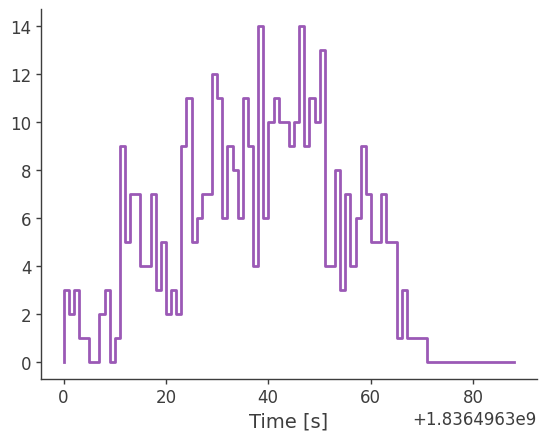

In [22]:
grb_bkg.get_raw_lightcurve(binned_data=data_path / "tsel_binned_data_local_grbdc3.hdf5", output_name="lc")
time, rate = np.loadtxt("lc.dat", skiprows=1, unpack=True)
grb_bkg.binned_data.project('Time').plot()

Now we use the make_minsn_tslices function to create N time slices with a minimum signal to noise of 10.
You can customize the requirement of a minimum signal to noise to create less or more bins.
We used them to slice the data in time. 

In [28]:
min_sn=10
yaml_path=data_path / "bin_galbk_grbdc3.yaml"
hdf5_path=data_path / "tsel_binned_data_local_galbk_grbdc3.hdf5"
tmins,tmaxs=make_minsn_tslices(yaml_path,hdf5_path,min_sn)
len(tmins)

4

Now we used them to slice the data in time. We perform N spectral fits to determine fluxes and spectral parameters as a function of time. We save all the time series in a text file.

In [25]:
#
#Initialize empty vectors that will be filled at each step.
#
tmins_lc=np.array([])
tmaxs_lc=np.array([])
tmeds_lc=np.array([])
e_tmeds_lc=np.array([])
#
cts_lc=np.array([])
fls=np.array([])
e_low_fls=np.array([])
e_hi_fls=np.array([])
#
pars_bk=np.array([])
epars_bk=np.array([])
#
par_epar=np.array([])
#
for i in range(len(tmaxs)):
    #
    #Slice the orientation file into the time interval
    #
    ori_min = Time(tmins[i],format = 'unix')
    ori_max = Time(tmaxs[i],format = 'unix')
    sc_orientation = ori.source_interval(ori_min, ori_max)
    #
    #
    #Find the index of time axes corresponding to the limits of the tmins[i],tmaxs[i].
    #These are used to slice the data in time in the fit setup.
    #
    #
    sou_min = np.where(grb_bkg.binned_data.axes['Time'].edges.value >= tmins[i])[0][0]
    sou_max = np.where(grb_bkg.binned_data.axes['Time'].edges.value <= tmaxs[i])[0][-1]
    #
    #Save the time bin edges and middle points for plotting later.
    #
    tmin_lc=grb_bkg.binned_data.axes['Time'].edges.value[sou_min]
    tmins_lc=np.append(tmins_lc,tmin_lc)
    #
    tmax_lc=grb_bkg.binned_data.axes['Time'].edges.value[sou_max]
    tmaxs_lc=np.append(tmaxs_lc,tmax_lc)
    #
    dt=(tmax_lc-tmin_lc) #total duration of the time bin
    tmed_lc=tmin_lc+0.5*dt#midpoint of time bins
    tmeds_lc=np.append(tmeds_lc,tmed_lc)#midpoints of the time bin
    hdt=dt/2 #half duration of the time bin i.e symmetric error for t_med
    e_tmeds_lc=np.append(e_tmeds_lc,hdt)#half duration of the time bin i.e symmetric error for t_med
    #
    #Define the background parameters
    #
    #
    bkg_par = Parameter("background_cosi",                                                                          # background parameter
                    10,                                                                                        # initial value of parameter
                    min_value=0,                                                                                # minimum value of parameter
                    max_value=10,                                                                                # maximum value of parameter
                    delta=1e-3,                                                                                 # initial step used by fitting engine
                    desc="Background parameter for cosi")
    #
    #
    #HERE's the key point. In the fit setup data, the grb_bkg data are sliced in Time in the interval tmins[i],tmaxs[i]
    #
    cosi = COSILike("cosi",                                                                                         # COSI 3ML plugin
                    dr = dr,                                                                                        # detector response
                    data = grb_bkg.binned_data.slice[{'Time':slice(sou_min,sou_max)}].project('Em', 'Phi', 'PsiChi'), # data (source+background)
                    bkg = bkg.binned_data.project('Em', 'Phi', 'PsiChi'),# background model 
                    sc_orientation = sc_orientation,                                                                # spacecraft orientation
                    nuisance_param = bkg_par)  # background parameter

    #
    
    source = PointSource("source",                 # Name of source (arbitrary, but needs to be unique)
                     l = l,                        # Longitude (deg)
                     b = b,                        # Latitude (deg)
                     spectral_shape = spectrum)    # Spectral model

    model = Model(source)  # Model with single source. If we had multiple sources, we would do Model(source1, source2, ...)

    # Optional: if you want to call get_log_like manually, then you also need to set the model manually
    # 3ML does this internally during the fit though
    cosi.set_model(model)    
    plugins = DataList(cosi) # If we had multiple instruments, we would do e.g. DataList(cosi, lat, hawc, ...)
    #
    like = JointLikelihood(model, plugins, verbose = False)
    like.fit()
    results = like.results
    #
    #
    #Obtain counts in time slices:
    #
    cts=np.sum(grb_bkg.binned_data.slice[{'Time':slice(sou_min,sou_max)}])
    cts_lc=np.append(cts_lc,cts)
    #
    #Obtain parameters:
    #
    #bk
    #
    par_bk=results.get_variates("background_cosi").median
    pars_bk=np.append(pars_bk,par_bk)
    epar_bk=results.get_variates("background_cosi").std
    epars_bk=np.append(epars_bk,epar_bk)   
    #
    #These are dictionaries of parameters values and errors.
    #
    par_bf= {par.name:results.get_variates(par.path).median
                  for par in results.optimized_model["source"].parameters.values()
                  if par.free}
    #
    epar_bf= {par.name:results.get_variates(par.path).std
                  for par in results.optimized_model["source"].parameters.values()
                  if par.free}
    #
    par_list = list(par_bf.keys()) #This is a list of the parameter names.
    for j in range(len(par_list)):
        par_epar=np.append(par_epar,par_bf[par_list[j]])
        par_epar=np.append(par_epar,epar_bf[par_list[j]])         
    #
    #Obtain fluxes:
    #Here I use the 3ML method to ge integrated flux in an energy range.
    #I use the energy range from the data 100--10000 keV
    #
    threeML_config.point_source.integrate_flux_method = "trapz"
    result_fl=results.get_flux(
        ene_min=100. * u.keV,
        ene_max= 10000.* u.keV,
        confidence_level=0.95,
        sum_sources=True,
        flux_unit="1/(cm2 s)"
    )
    #
    fl=result_fl["flux"].values[0].value
    fls=np.append(fls,fl)
    e_low_fl=np.abs(result_fl["low bound"].values[0].value-fl)
    e_low_fls=np.append(e_low_fls, e_low_fl)
    e_hi_fl=result_fl["hi bound"].values[0].value-fl
    e_hi_fls=np.append(e_hi_fls, e_hi_fl)
    #
    #
    #Save a plot of the current fit.
    #
    sliced_data=grb_bkg.binned_data.slice[{'Time':slice(sou_min,sou_max)}]
    expectation = cosi._expected_counts['source']
    cts_exp=expectation.project('Em').todense().contents + (bkg_par.value * bkg.binned_data.project('Em').todense().contents)
    plot_filename=str("fit_"+str(i)+".pdf")
    plot_fit(sliced_data, cts_exp, plot_filename)
#
#Save lc in in a text file:
#
lc=np.vstack((tmeds_lc,e_tmeds_lc,cts_lc,fls,e_low_fls,e_hi_fls,pars_bk,epars_bk)).T
nbins=len(tmeds_lc)
npars=2*len(par_list)
lc_par=par_epar.reshape(nbins,npars)
lc_all=np.hstack((lc,lc_par))
fl_list=['t','e_t','cts','fl','e+_fl','e-_fl','bk','e_bk']
par_list = list(par_bf.keys())
header=fl_list+par_list
np.savetxt("spec_lc.dat", lc_all, delimiter=" ",header=str(header))






13:50:24 INFO      set the minimizer to minuit                                             ]8;id=23977;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=713325;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

Adding 1e-12 to each bin of the expectation to avoid log-likelihood = -inf.


         WARNING   get_number_of_data_points not implemented, values for statistical        ]8;id=233121;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/plugin_prototype.py\plugin_prototype.py]8;;\:]8;id=97743;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/plugin_prototype.py#130\130]8;;\
                  measurements such as AIC or BIC are unreliable                                                   

         WARNING   49.94 percent of samples have been thrown away because they failed the  ]8;id=316658;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=828281;file:///opt/anaconda3/envs/cosipy_lctutorial/lib/python3.10/site-packages/threeML/analysis_results.py#1739\1739]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

...

,-log(likelihood)
cosi,267.081685
total,267.081685


Values of statistical measures:

,statistical measures
AIC,532.16337
BIC,534.16337


processing MLE analyses:   0%|                                                     | 0/1 [00:00<?, ?it/s]


WARNING RuntimeWarning: divide by zero encountered in divide


WARNING RuntimeWarning: invalid value encountered in divide



## Plotting the time series.

Now we plot the time-series of fluxes, counts and fitted parameters. We convert the time in mjd for plotting. 
We use the raw lightcurve and the average flux injected as comparison. We plot the counts in each time bins to check that the fits had a reasonable statistics. In the future, we may be able to compute a goodness of fit in each time bin with 3ML.

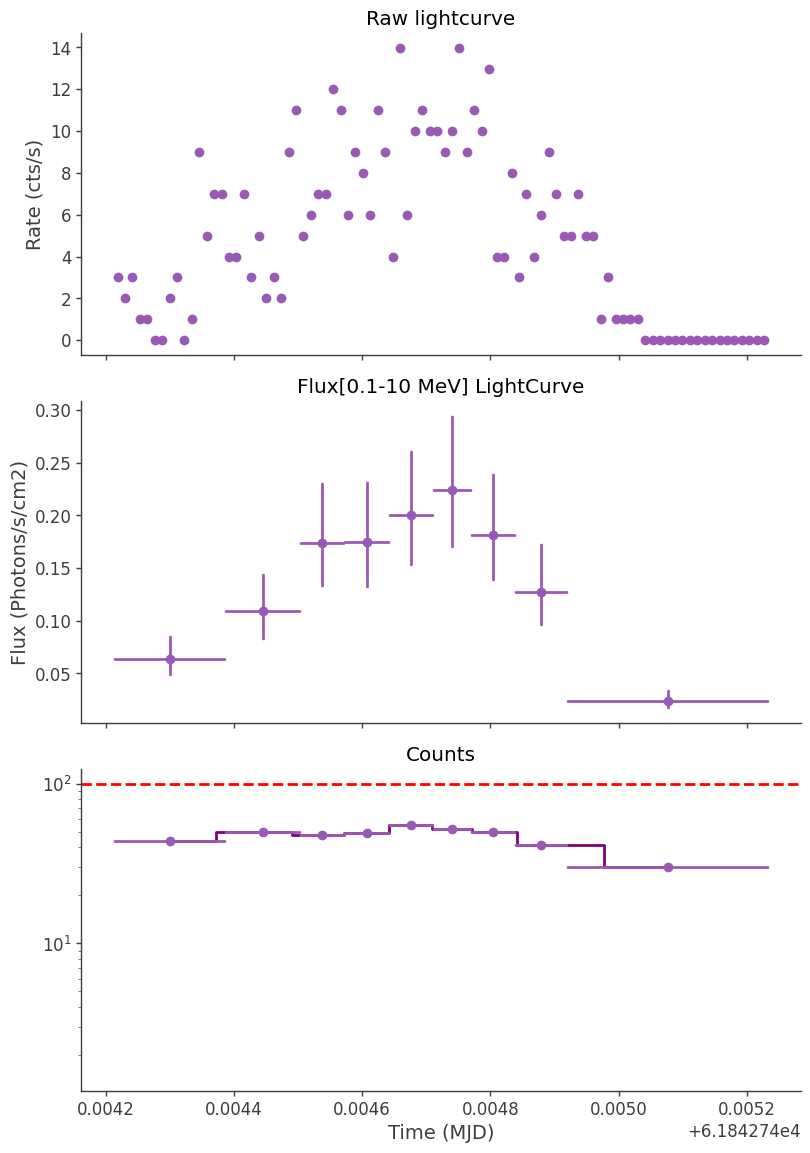

In [26]:
time_mjd=Time(time,format='unix').mjd
tmeds_mjd=Time(tmeds_lc, format='unix').mjd
e_tmeds_mjd=TimeDelta(e_tmeds_lc, format='sec').to('day').value

cm = 1/2.54
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(21*cm, 29.7*cm))
#
# Raw Lightcurve
axs[0].scatter (time_mjd, rate)
axs[0].set_title('Raw lightcurve')
axs[0].set_ylabel('Rate (cts/s)')
#
# Flux Lightcurve
axs[1].errorbar(tmeds_mjd, fls, xerr=e_tmeds_mjd, yerr=[e_low_fls,e_hi_fls],fmt='o', capsize=1)
axs[1].set_title('Flux[0.1-10 MeV] LightCurve')
axs[1].set_ylabel('Flux (Photons/s/cm2)')
#
#Counts in log scale. To check that the fits have reasonable statistics.
axs[2].set_yscale('log')
axs[2].step(tmeds_mjd, cts_lc, where='mid',color='purple')
axs[2].errorbar (tmeds_mjd, cts_lc,xerr=e_tmeds_mjd,fmt='o', capsize=1)
axs[2].set_title('Counts')
axs[2].set_xlabel('Time (MJD)')
axs[2].axhline(y=100, color='red', linestyle='--')
#
#
# Adjust spacing between subplots
plt.tight_layout()
plt.savefig("raw_flux_counts_lc.pdf", dpi=300)

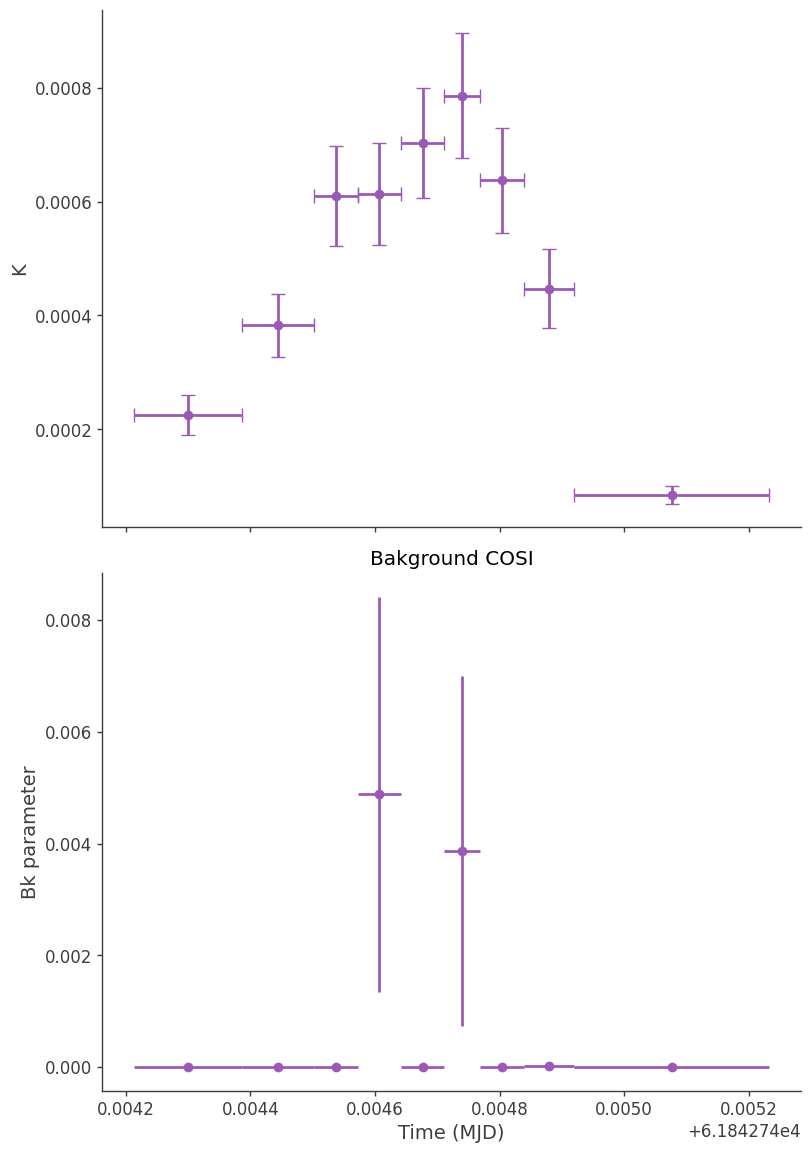

In [27]:
#
#Plot the free parameters as a function of time.
#
npar=len(par_list)
cm = 1/2.54 
fig, axs = plt.subplots(npar+1, 1, sharex=True, figsize=(21*cm, 29.7*cm))

h=np.arange(0, 2*npar, 2)
for i in range(npar):
    axs[i].errorbar(tmeds_mjd, lc_par[:,h[i]], xerr=e_tmeds_mjd, yerr=lc_par[:,h[i]+1], fmt='o', capsize=5)
    axs[i].set_ylabel(par_list[i])

axs[npar].errorbar(tmeds_mjd, pars_bk, xerr=e_tmeds_mjd, yerr=epars_bk, fmt='o')
axs[npar].set_title('Bakground COSI')
axs[npar].set_xlabel('Time (MJD)')
axs[npar].set_ylabel('Bk parameter')

# Adjust spacing between subplots
plt.tight_layout()
plt.savefig("specpars_bk_lc.pdf", dpi=300)